Modelo de Regressão Logística

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [25]:
# importação dos arquivos
df_train = pd.read_csv("./dados_projeto/treino.csv")
df_test1 = pd.read_csv("./dados_projeto/teste1.csv")
df_test2 = pd.read_csv("./dados_projeto/teste2.csv")

C:\Users\gabri\AppData\Local\Temp\ipykernel_33436\343499087.py:2: DtypeWarning: Columns (0: EXTRAPU1_N, 1: EXTRAPUL_O, 2: AGRAVOUTDE, 3: OUTRAS_DES, 4: BAC_APOS_6) have mixed types. Specify dtype option on import or set low_memory=False.
  df_train = pd.read_csv("./dados_projeto/treino.csv")


In [26]:
# tipos de variáveis
categorical_onehot_encoder_cols = ['AGRAVTABAC', 'AGRAVDROGA', 'AGRAVAIDS', 'AGRAVDIABE', 'HIV','POP_RUA', 'POP_LIBER', 'POP_IMIG', 'CS_SEXO', 'BACILOSC_E', 'CULTURA_ES', 'RAIOX_TORA', 'CS_RACA', 'TRATAMENTO', 'CULTURA_OU', 'HISTOPATOL', 'TRATSUP_AT']
categorical_target_encoder_cols = ['SG_UF_NOT']
ordinal_cols = ['CS_ESCOL_N', 'cat_idade']
numerical_cols = ['idade_anos']
target_col = ['ltfu']
feature_cols = categorical_onehot_encoder_cols + categorical_target_encoder_cols + ordinal_cols + numerical_cols

In [27]:
# categoriza a idade da pessoa
from sklearn.preprocessing import FunctionTransformer

def categorize_age(age):
  if age <= 29:
    return 'jovem_adulto'
  elif age <= 49:
    return 'adulto_meia_idade'
  elif age <= 64:
    return 'adulto_transicao_para_idoso'
  elif age >= 65:
    return 'idoso'
  else:
    return 'ignorado'

def apply_age_categorization(df):
  df['cat_idade'] = df['idade_anos'].apply(categorize_age)
  return df

age_categorizer = FunctionTransformer(apply_age_categorization)

In [28]:
# seleciona as colunas desejadas
def filter_cols(df):
  return df[feature_cols]

column_selector = FunctionTransformer(filter_cols)

In [29]:
# mapeia os dados do dataframe
categorical_onehot_encoder_mapping = {
  'CS_RACA': {
    1: 'branca',
    2: 'preta',
    3: 'amarela',
    4: 'parda',
    5: 'indigena',
    9: 'ignorado',
    0: None
  },
  'AGRAVTABAC': {
    1: 'sim',
    2: 'nao',
    9: 'ignorado',
    0: None
  },
  'AGRAVDROGA': {
    1: 'sim',
    2: 'nao',
    9: 'ignorado',
    0: None
  },
  'AGRAVAIDS': {
    1: 'sim',
    2: 'nao',
    9: 'ignorado',
    0: None
  },
  'AGRAVDIABE': {
    1: 'sim',
    2: 'nao',
    9: 'ignorado',
    0: None
  },
  'HIV': {
    1: 'positivo',
    2: 'negativo',
    3: 'em_andamento',
    4: 'realizado',
    0: None
  },
  'TRATSUP_AT': {
    1: 'sim',
    2: 'nao',
    9: 'ignorado',
    0: None
  },
  'POP_RUA': {
    1: 'sim',
    2: 'nao',
    9: 'ignorado',
    0: None
  },
  'POP_LIBER': {
    1: 'sim',
    2: 'nao',
    9: 'ignorado',
    0: None
  },
  'POP_IMIG': {
    1: 'sim',
    2: 'nao',
    9: 'ignorado',
    0: None
  },
  'BACILOSC_E': {
    1: 'positiva',
    2: 'negativa',
    3: 'nao_realizada',
    4: 'nao_se_aplica',
    0: None
  },
  'RAIOX_TORA': {
    1: 'suspeito',
    2: 'normal',
    3: 'outra_patologia',
    4: 'nao_realizado',
    0: None
  },
  'TRATAMENTO': {
    1: 'caso_novo',
    2: 'recidiva',
    3: 'reingresso_apos_abandono',
    4: 'nao_sabe',
    5: 'transferencia',
    6: 'pos_obito',
    0: None
  },
  'CULTURA_ES': {
    1: 'positiva',
    2: 'negativa',
    3: 'em_andamento',
    4: 'nao_realizada',
    0: None
  },
  'CULTURA_OU': {
    1: 'positiva',
    2: 'negativa',
    3: 'em_andamento',
    4: 'nao_realizada',
    0: None
  },
  'HISTOPATOL': {
    1: 'baar_positivo',
    2: 'sugestivo_de_tb',
    3: 'nao_sugestivo_de_tb',
    4: 'em_andamento',
    5: 'nao_realizado',
    0: None
  }
}
categorical_target_encoder_mapping = {
  'SG_UF_NOT': {
    11: 'ro', 
    12: 'ac', 
    13: 'am', 
    14: 'rr', 
    15: 'pa', 
    16: 'ap', 
    17: 'to',
    21: 'ma', 
    22: 'pi', 
    23: 'ce', 
    24: 'rn', 
    25: 'pb', 
    26: 'pe', 
    27: 'al', 
    28: 'se', 
    29: 'ba',
    31: 'mg', 
    32: 'es', 
    33: 'rj', 
    35: 'sp',
    41: 'pr', 
    42: 'sc', 
    43: 'rs',
    50: 'ms', 
    51: 'mt', 
    52: 'go', 
    53: 'df'
  }
}
ordinal_mapping = {
  'CS_ESCOL_N': {
    0: 'analfabeto',
    1: '1a_a_4a_serie_incompleta_do_ef',
    2: '4a_serie_completa_do_ef',
    3: '5a_a_8a_serie_incompleta_do_ef',
    4: 'ensino_fundamental_completo',
    5: 'ensino_medio_incompleto',
    6: 'ensino_medio_completo',
    7: 'educacao_superior_incompleta',
    8: 'educacao_superior_completa',
    9: 'ignorado',
    10: 'nao_se_aplica'
  }
}

def map_df_data(df, cols_list, mapping_dict):
  for col in cols_list:
    if col in mapping_dict.keys():
      df[col] = df[col].map(mapping_dict[col])
  return df

def map_to_lowercase(df, col):
  df[col] = df[col].str.lower()
  return df

def apply_df_mapping(df):
  df_mapped = map_df_data(df, categorical_onehot_encoder_cols, categorical_onehot_encoder_mapping)
  df_mapped = map_df_data(df_mapped, categorical_target_encoder_cols, categorical_target_encoder_mapping)
  df_mapped = map_df_data(df_mapped, ordinal_cols, ordinal_mapping)
  df_mapped = map_to_lowercase(df_mapped, 'CS_SEXO')
  return df_mapped 

column_mapper = FunctionTransformer(apply_df_mapping)

In [30]:
# separação das features e do alvo
X_train = df_train.drop(columns=target_col)
y_train = df_train[target_col[0]]

In [31]:
# imputação dos missings
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, TargetEncoder, PowerTransformer

numerical_prep = Pipeline([
  ('imputer', IterativeImputer(random_state=32)),
  ('scaler', PowerTransformer())
])

categorical_onehot_encoder_prep = Pipeline([
  ('imputer', SimpleImputer(strategy='most_frequent')),
  ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

categorical_target_encoder_prep = Pipeline([
  ('imputer', SimpleImputer(strategy='most_frequent')),
  ('encoder', TargetEncoder(cv=5))
])

ordinal_prep = Pipeline([
  ('imputer', SimpleImputer(strategy='most_frequent')),
  ('encoder', TargetEncoder(cv=5))
])

preprocessor = ColumnTransformer([
  ('num', numerical_prep, numerical_cols),
  ('cat_onehot_encoder', categorical_onehot_encoder_prep, categorical_onehot_encoder_cols),
  ('cat_target_encoder', categorical_target_encoder_prep, categorical_target_encoder_cols),
  ('ord', ordinal_prep, ordinal_cols)
])

In [32]:
# xgboost
from xgboost import XGBClassifier

xgboost_model = XGBClassifier(n_estimators=90, learning_rate=0.3, random_state=22, max_depth=3, n_jobs=-1)

In [33]:
# pipeline
pipeline = Pipeline(
  steps = [
    ('age_cat', age_categorizer),
    ('selector', column_selector),
    ('mapper', column_mapper),
    ('pre', preprocessor),
    ('clf', xgboost_model)
  ]
)

In [34]:
# grid
imbalance_ratio = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

grid = {
  'clf__reg_alpha':np.logspace(-2, 1, 100),
  'clf__reg_lambda':np.logspace(-2, 1, 100),
  'clf__scale_pos_weight':[imbalance_ratio, 1]
}

In [35]:
# randomized search
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
  estimator=pipeline,
  param_distributions=grid,
  n_iter=70,
  cv=3,
  random_state=42,
  n_jobs=-1,
  verbose=3,
  scoring=['roc_auc', 'accuracy', 'recall', 'precision', 'f1'],
  refit='f1'
)

In [36]:
# treina o modelo
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 70 candidates, totalling 210 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'clf__reg_alpha': array([ 0.01 ... 10. ]), 'clf__reg_lambda': array([ 0.01 ... 10. ]), 'clf__scale_pos_weight': [4.149761107144818, 1]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",70
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","['roc_auc', 'accuracy', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strat

In [37]:
metrics = ["rank_test_recall", "rank_test_precision", "rank_test_f1",  "rank_test_roc_auc", "mean_fit_time", "mean_score_time", "mean_test_recall", "mean_test_precision", "mean_test_f1", "mean_test_roc_auc"]

# melhores hiperparâmetros
def show_best_hyperparams():
  return (f"melhores hiperparâmetros: {random_search.best_params_}")

# métricas treino
def show_metrics():
  return pd.DataFrame(random_search.cv_results_)[metrics].sort_values(by=["rank_test_f1"]).head()

In [38]:
# mostra melhores hiperparâmetros e métricas do treino inicial
print(show_best_hyperparams())
show_metrics()

melhores hiperparâmetros: {'clf__scale_pos_weight': 4.149761107144818, 'clf__reg_lambda': np.float64(1.072267222010323), 'clf__reg_alpha': np.float64(0.533669923120631)}


,rank_test_recall,rank_test_precision,rank_test_f1,rank_test_roc_auc,mean_fit_time,mean_score_time,mean_test_recall,mean_test_precision,mean_test_f1,mean_test_roc_auc
65,19,41,1,21,17.115317,3.584319,0.685046,0.390856,0.497131,0.789003
6,22,42,2,9,15.239491,4.871690,0.684780,0.390794,0.497027,0.789236
67,17,45,3,8,12.003827,3.212510,0.685302,0.390503,0.496967,0.789248
2,26,43,4,5,12.659253,4.186178,0.684433,0.390703,0.496932,0.789331
22,10,48,5,4,12.878300,5.438344,0.686108,0.390114,0.496927,0.789335


In [39]:
# testa o modelo no df_test1
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, RocCurveDisplay

X_test1 = df_test1.drop(columns=target_col)
y_test1 = df_test1[target_col[0]]

y_pred_test1 = random_search.predict(X_test1)
y_proba_test1 = random_search.predict_proba(X_test1)[:, 1]

def calc_scores(y_test, y_pred, y_proba):
  scores = {
    "accuracy":[accuracy_score(y_test, y_pred)],
    "recall":[recall_score(y_test, y_pred)],
    "precision":[precision_score(y_test, y_pred)],
    "f1_score":[f1_score(y_test, y_pred)],
    "auc_roc":[roc_auc_score(y_test, y_proba)]
    }
  return scores

scores_test1 = calc_scores(y_test1, y_pred_test1, y_proba_test1)
pd.DataFrame(scores_test1, index=["Teste1"])

,accuracy,recall,precision,f1_score,auc_roc
Teste1,0.749604,0.830325,0.674487,0.744337,0.847957


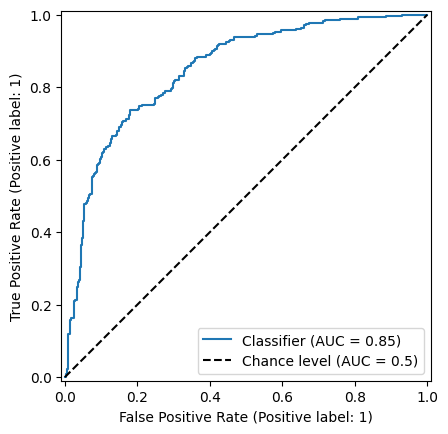

In [40]:
# curva ROC test1
def show_graphic_auc_roc(y_test, y_proba):
  RocCurveDisplay.from_predictions(y_test, y_proba, plot_chance_level=True)

show_graphic_auc_roc(y_test1, y_proba_test1)

In [41]:
# retreina o modelo
df_combined = pd.concat([df_train, df_test1], ignore_index=True)

X_combined = df_combined.drop(columns=target_col)
y_combined = df_combined[target_col[0]]

random_search.fit(X_combined, y_combined)

Fitting 3 folds for each of 70 candidates, totalling 210 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'clf__reg_alpha': array([ 0.01 ... 10. ]), 'clf__reg_lambda': array([ 0.01 ... 10. ]), 'clf__scale_pos_weight': [4.149761107144818, 1]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",70
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","['roc_auc', 'accuracy', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strat

In [42]:
# mostra melhores hiperparâmetros e métricas do treino final
print(show_best_hyperparams())
show_metrics()

melhores hiperparâmetros: {'clf__scale_pos_weight': 4.149761107144818, 'clf__reg_lambda': np.float64(0.012328467394420659), 'clf__reg_alpha': np.float64(0.7054802310718645)}


,rank_test_recall,rank_test_precision,rank_test_f1,rank_test_roc_auc,mean_fit_time,mean_score_time,mean_test_recall,mean_test_precision,mean_test_f1,mean_test_roc_auc
46,15,41,1,15,13.974665,4.471425,0.685769,0.390644,0.497187,0.788567
7,11,50,2,28,14.371715,4.235762,0.686226,0.390276,0.497145,0.788418
26,20,42,3,3,13.071026,4.161378,0.685039,0.390636,0.497054,0.788710
18,5,48,4,14,14.580177,4.166005,0.686409,0.390333,0.497028,0.788573
4,22,47,5,23,15.420945,4.258264,0.685012,0.390373,0.496856,0.788453


In [43]:
# testa o modelo no df_test2
X_test2 = df_test2.drop(columns=target_col)
y_test2 = df_test2[target_col[0]]

y_pred_test2 = random_search.predict(X_test2)
y_proba_test2 = random_search.predict_proba(X_test2)[:, 1]

scores_test2 = calc_scores(y_test2, y_pred_test2, y_proba_test2)
pd.DataFrame(scores_test2, index=["Teste2"])

,accuracy,recall,precision,f1_score,auc_roc
Teste2,0.793978,0.906393,0.816872,0.859307,0.867184


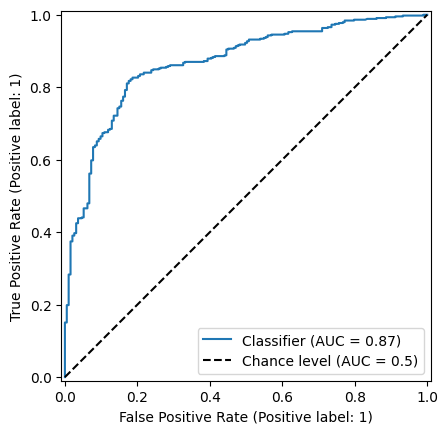

In [44]:
# curva ROC test2
show_graphic_auc_roc(y_test2, y_proba_test2)

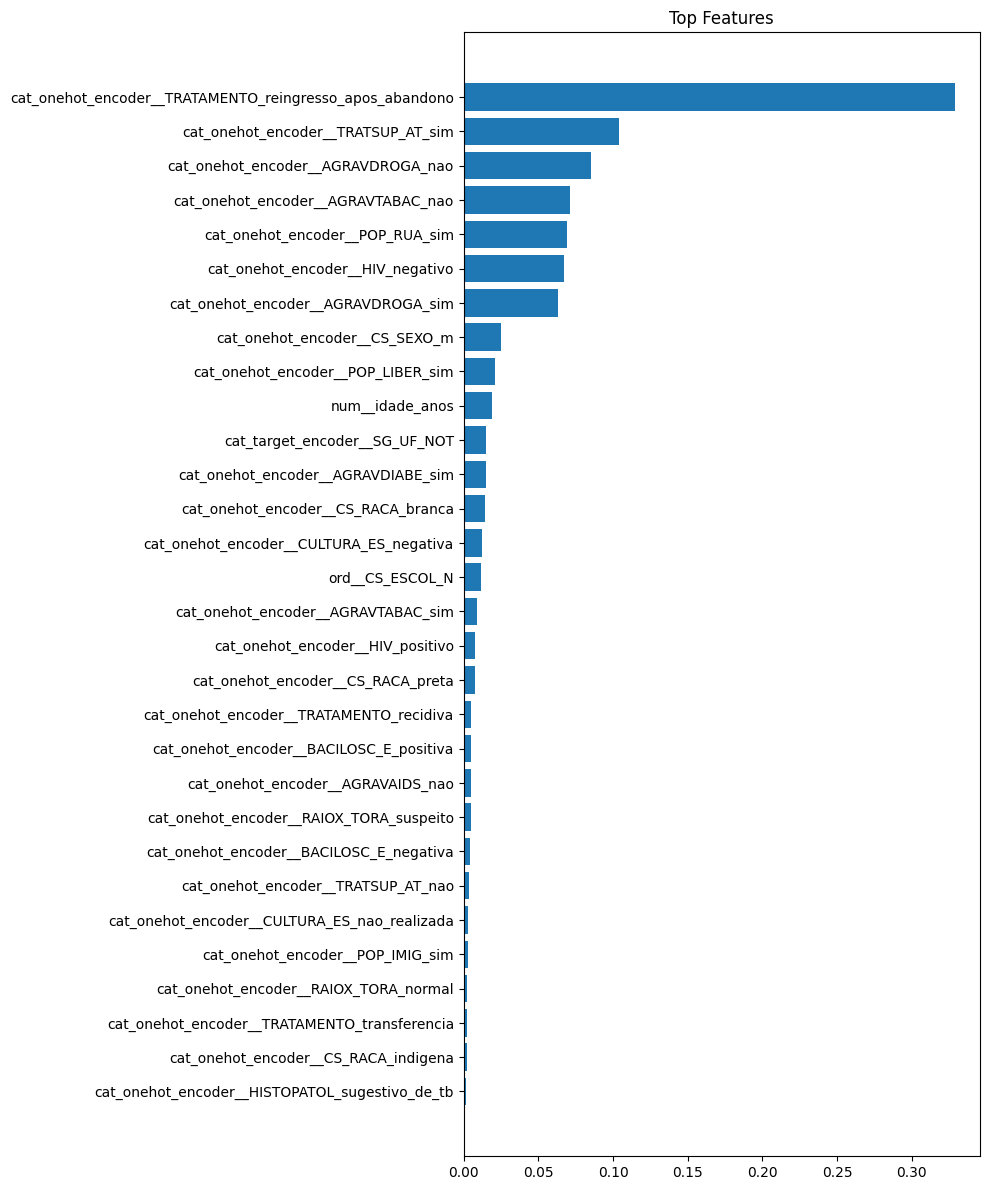

In [45]:
# feature importances
feature_names = random_search.best_estimator_['pre'].get_feature_names_out()
importances = random_search.best_estimator_['clf'].feature_importances_

feature_importance_df = pd.DataFrame({'feature':feature_names, 'importance':importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

top_features = feature_importance_df.head(30)

plt.figure(figsize=(10, 12))
plt.barh(top_features['feature'][::-1], top_features['importance'][::-1])
plt.title('Top Features')
plt.tight_layout()
plt.show()

In [46]:
# extrai o melhor modelo
import joblib

joblib.dump(random_search.best_estimator_, 'xgboost_model.pkl')

['xgboost_model.pkl']